<a href="https://colab.research.google.com/github/MridulSharma02/Deep-Learning-2025-26-Mridul-Sharma/blob/main/DL_Experiment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aakash50897/churn-modellingcsv")

print("Path to dataset files:", path)

100%|██████████| 262k/262k [00:00<00:00, 27.1MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/aakash50897/churn-modellingcsv/versions/1


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
dataset=pd.read_csv('/kaggle/input/churn-modellingcsv/Churn_Modelling.csv')
print("Top 10 Rows of Dataset")
print(dataset.head(10))

Top 10 Rows of Dataset
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   
5          6    15574012       Chu          645     Spain    Male   44   
6          7    15592531  Bartlett          822    France    Male   50   
7          8    15656148    Obinna          376   Germany  Female   29   
8          9    15792365        He          501    France    Male   44   
9         10    15592389        H?          684    France    Male   27   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86          

In [ ]:
x=dataset.drop(['RowNumber','CustomerId','Surname','Exited'],axis=1)
y=dataset['Exited']

x=pd.get_dummies(x,columns=['Geography'],drop_first=True)

x['Gender']=x['Gender'].map({'Male':1,'Female':0})

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

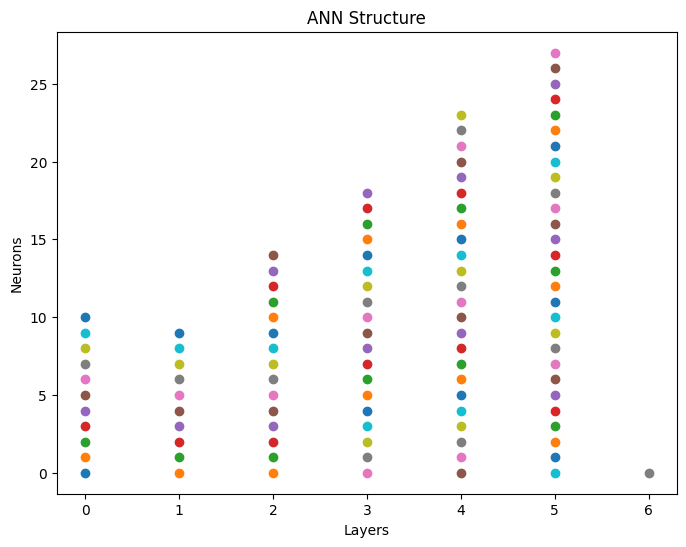

In [ ]:
layers=[x_train.shape[1],10,15,19,24,28,1]
plt.figure(figsize=(8,6))
for i,layer in enumerate(layers):
  for j in range(layer):
    plt.scatter(i,j)
plt.title("ANN Structure")
plt.xlabel("Layers")
plt.ylabel("Neurons")
plt.show()

In [ ]:
model = Sequential()

model.add(Dense(10, activation='relu', input_dim=x_train.shape[1]))
model.add(Dense(15, activation='relu'))
model.add(Dense(19, activation='relu'))
model.add(Dense(24, activation='relu'))
model.add(Dense(28, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
history = model.fit(
    x_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(x_test, y_test)
)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7695 - loss: 0.5682 - val_accuracy: 0.7975 - val_loss: 0.4669
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.7994 - loss: 0.4467 - val_accuracy: 0.7980 - val_loss: 0.4448
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8036 - loss: 0.4330 - val_accuracy: 0.8145 - val_loss: 0.4342
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8154 - loss: 0.4159 - val_accuracy: 0.8195 - val_loss: 0.4210
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8263 - loss: 0.4067 - val_accuracy: 0.8385 - val_loss: 0.3902
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8464 - loss: 0.3758 - val_accuracy: 0.8495 - val_loss: 0.3586
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8705 - loss: 0.3292 - val_accuracy: 0.8560 - val_loss: 0.3511
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8639 - loss: 0.3388 - val_ac

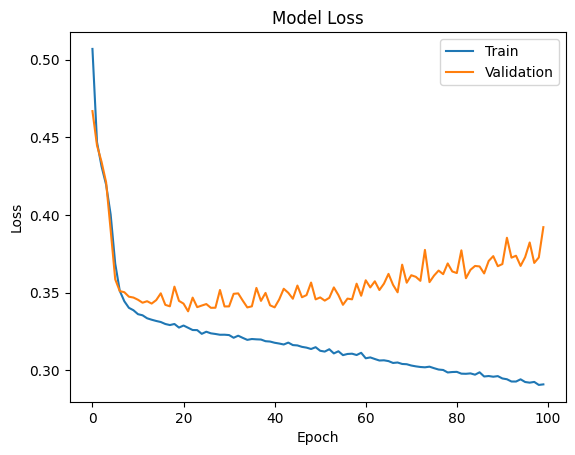

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])
plt.show()

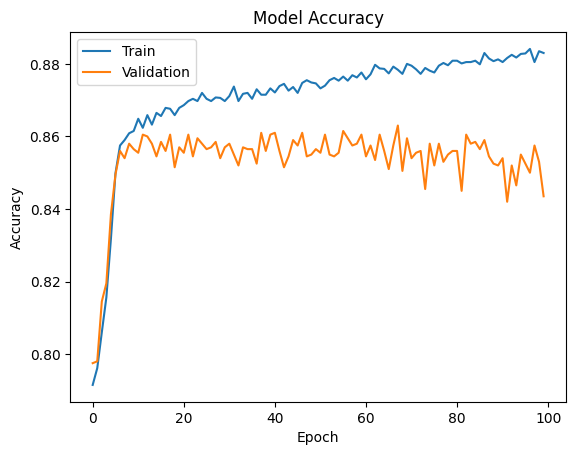

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])
plt.show()